# UMAP Analysis — Standalone Notebook
Run `main.py` first to generate `results/all_results.pkl` and trained model weights.
This notebook loads everything and lets you explore latents interactively.

In [ ]:
import os
import gc

import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import numpy as np
import torch

# ── project imports ───────────────────────────────────────────────────────────
from Data_generation import CoinDataset, coin_generation, flower_process_generation
from Flower_process_generation import FlowerDataset
from OneHot_model import OneHotDecoder
from Training_model import make_chunked_loader, _loader
from Model_analysis import (
    latent_extraction,
    perplexity_calculation,
    plot_umap,
    statistical_complexity,
    statistical_complexity_empirical,
    savefig,
    mkdir,
)

/Users/tisornnaphattalung/Desktop/Quantum/URECA/.venv_URECA_qt_llm/lib/python3.12/site-packages/umap/umap_.py:2462: UserWarning: n_neighbors is larger than the dataset size; truncating to X.shape[0] - 1
  warn(


umap-learn JIT warm-up succeeded


In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# CONFIG — mirror the values used during training
# ══════════════════════════════════════════════════════════════════════════════
EVAL_CFG = dict(
    # model architecture — must match what was trained
    d_model        = 64,
    max_len        = 2000,       # full sequence length (PE table covers this)
    n_layers       = 2,
    # new data generation
    num_samples    = 500,        # sequences to generate for evaluation
    batch_size     = 32,
    # coin
    coin_p1        = 0.3,  coin_q1 = 0.4,
    coin_seq_len   = 2000,
    coin_num_token = 3,
    coin_p2        = 0.1,  coin_q2 = 0.9,
    coin_seq_len_12 = 500,
    # flower
    flower_n       = 6,    flower_m = 4,
    flower_seq_len = 2000,
    # analysis
    umap_n_pts       = 1000,
    umap_n_neighbors = 200,
    max_batches      = 20,
)

In [16]:
# ══════════════════════════════════════════════════════════════════════════════
# HELPERS
# ══════════════════════════════════════════════════════════════════════════════
def load_model(weights_path: str, num_token: int, cfg: dict,
               mode: str) -> OneHotDecoder:
    """Instantiate OneHotDecoder and load saved weights onto CPU."""
    model = OneHotDecoder(
        token_size = num_token,
        d_model    = cfg["d_model"],
        max_len    = cfg["max_len"],
        mode       = mode,
        n_layers   = cfg["n_layers"],
    )
    state = torch.load(weights_path, map_location="cpu")
    model.load_state_dict(state)
    model.eval()
    print(f"  loaded  {weights_path}  ({mode})")
    return model


def evaluate_one(tag: str, model: OneHotDecoder, loader_ana,
                 num_token: int, out_dir: str, cfg: dict,
                 p=None, q=None, mode="forward",
                 k_complexity=2, use_t="last"):
    """
    Run all analysis for a single model on loader_ana (freshly generated data).

    Returns dict with perplexity, S_emp, S_theory.
    """
    res = {"tag": tag, "mode": mode}
    mkdir(out_dir)

    # ── Perplexity ────────────────────────────────────────────────────────────
    # perplexity_calculation collects all logits then computes global CE loss
    # → true dataset-level perplexity (not mean of batch means)
    ppl = perplexity_calculation(model, loader_ana,
                                 max_batches=cfg["max_batches"])
    res["perplexity"] = ppl
    print(f"  [{tag}]  perplexity = {ppl:.4f}")

    # ── UMAP ─────────────────────────────────────────────────────────────────
    # latent_extraction always passes batch[0] to model
    # flatten → (N*T, D) → first umap_n_pts rows  (testing.ipynb convention)
    try:
        latents, inp_arr, tgt_arr = latent_extraction(
            model, loader_ana, max_batches=cfg["max_batches"])

        flat_lat = latents.reshape(-1, latents.shape[-1])   # (N*T, D)
        # colour fix: backward model's actual input is batch[1] = tgt_arr
        if mode == "backward":
            flat_inp = tgt_arr.reshape(-1)
        else:
            flat_inp = inp_arr.reshape(-1)

        # wrap into (N*T, 1, D) / (N*T, 1) shape that plot_umap expects
        flat_lat_wrap = flat_lat[:, np.newaxis, :]
        flat_inp_wrap = flat_inp[:, np.newaxis]

        _, coords = plot_umap(
            flat_lat_wrap, flat_inp_wrap, num_token,
            title=tag,
            save_path=os.path.join(out_dir, f"{tag}_umap.png"),
            n_pts=cfg["umap_n_pts"],
        )
        res["umap_coords"] = coords
    except Exception as e:
        print(f"  UMAP failed: {e}")
        res["umap_coords"] = None

    # ── Statistical complexity ────────────────────────────────────────────────
    try:
        S_emp = statistical_complexity_empirical(
            model, loader_ana,
            max_batches=cfg["max_batches"],
            use_t=use_t,
            k=k_complexity,
        )
        res["S_emp"] = S_emp
        if p is not None and q is not None:
            S_th = statistical_complexity(p, q, mode=mode)
            res["S_theory"] = S_th
            print(f"  [{tag}]  S_emp={S_emp:.4f}  S_theory={S_th:.4f}  "
                  f"err={abs(S_emp - S_th):.4f}")
        else:
            print(f"  [{tag}]  S_emp={S_emp:.4f}")
    except Exception as e:
        print(f"  complexity failed: {e}")
        res["S_emp"] = float("nan")

    return res


def compare_plot(tag: str, res_fw: dict, res_bw: dict,
                 out_dir: str, p=None, q=None):
    """
    Side-by-side bar: perplexity + complexity for FW vs BW.
    """
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    # Perplexity bar
    ax = axes[0]
    vals = [res_fw["perplexity"], res_bw["perplexity"]]
    bars = ax.bar(["Forward", "Backward"], vals,
                  color=["#4c72b0", "#dd8452"], alpha=0.85, edgecolor="k")
    ax.bar_label(bars, fmt="%.4f", padding=3, fontsize=10)
    ax.set_ylabel("Perplexity  [exp(CE loss)]")
    ax.set_title(f"{tag} — perplexity on new data", fontweight="bold")
    ax.grid(True, alpha=0.3, axis="y")

    # Complexity bar
    ax = axes[1]
    fw_v = [res_fw.get("S_emp", 0), res_fw.get("S_theory", 0)]
    bw_v = [res_bw.get("S_emp", 0), res_bw.get("S_theory", 0)]
    x = np.arange(2)
    ax.bar(x - 0.2, fw_v, 0.35, label="Forward",  color="#4c72b0", alpha=0.85)
    ax.bar(x + 0.2, bw_v, 0.35, label="Backward", color="#dd8452", alpha=0.85)
    ax.set_xticks(x)
    ax.set_xticklabels(["Empirical", "Theoretical"])
    ax.set_ylabel("Statistical Complexity (bits)")
    ax.set_title(f"{tag} — complexity on new data", fontweight="bold")
    ax.legend(); ax.grid(True, alpha=0.3, axis="y")

    fig.suptitle(f"{tag} — evaluation on freshly generated data",
                 fontsize=12, fontweight="bold")
    fig.tight_layout()
    savefig(fig, os.path.join(out_dir, f"{tag}_eval_compare.png"))


# ══════════════════════════════════════════════════════════════════════════════
# EXPERIMENT EVALUATORS
# ══════════════════════════════════════════════════════════════════════════════
def eval_coin(tag: str, p: float, q: float, seq_len: int,
              models_dir: str, out_root: str, cfg: dict):
    odir      = mkdir(os.path.join(out_root, tag))
    num_token = cfg["coin_num_token"]
    print(f"\n{'='*60}\n  EVAL — {tag}  (p={p}, q={q})\n{'='*60}")

    # Generate fresh data
    data, _ = coin_generation(
        num_samples=cfg["num_samples"], seq_len=seq_len, p=p, q=q)
    ds         = CoinDataset(data, seq_len=seq_len)
    loader_ana = _loader(ds, cfg["batch_size"])

    # Load weights
    fw_path = os.path.join(models_dir, f"{tag}_fw.pt")
    bw_path = os.path.join(models_dir, f"{tag}_bw.pt")
    if not os.path.exists(fw_path) or not os.path.exists(bw_path):
        print(f"  weights not found — skipping {tag}")
        return

    model_fw = load_model(fw_path, num_token, cfg, mode="forward")
    model_bw = load_model(bw_path, num_token, cfg, mode="backward")

    res_fw = evaluate_one(f"{tag}_fw", model_fw, loader_ana, num_token,
                          odir, cfg, p=p, q=q, mode="forward",
                          k_complexity=2, use_t="last")

    res_bw = evaluate_one(f"{tag}_bw", model_bw, loader_ana, num_token,
                          odir, cfg, p=p, q=q, mode="backward",
                          k_complexity=3, use_t="first")

    compare_plot(tag, res_fw, res_bw, odir, p=p, q=q)
    gc.collect()
    return res_fw, res_bw


def eval_flower(tag: str, n: int, m: int,
                models_dir: str, out_root: str, cfg: dict):
    odir      = mkdir(os.path.join(out_root, tag))
    num_token = n + m
    print(f"\n{'='*60}\n  EVAL — {tag}  (n={n}, m={m})\n{'='*60}")

    # Generate fresh data (fixed dice for reproducibility)
    rng        = np.random.default_rng(99)   # different seed from training (42)
    dice_probs = rng.dirichlet(np.ones(m), size=n)
    data, _ = flower_process_generation(
        num_samples=cfg["num_samples"],
        seq_len=cfg["flower_seq_len"],
        n=n, m=m, dice_probs=dice_probs)
    seq_len_f  = len(data[0])
    ds         = FlowerDataset(data, seq_len=seq_len_f)
    loader_ana = _loader(ds, cfg["batch_size"])

    fw_path = os.path.join(models_dir, f"{tag}_fw.pt")
    bw_path = os.path.join(models_dir, f"{tag}_bw.pt")
    if not os.path.exists(fw_path) or not os.path.exists(bw_path):
        print(f"  weights not found — skipping {tag}")
        return

    model_fw = load_model(fw_path, num_token, cfg, mode="forward")
    model_bw = load_model(bw_path, num_token, cfg, mode="backward")

    res_fw = evaluate_one(f"{tag}_fw", model_fw, loader_ana, num_token,
                          odir, cfg, mode="forward",
                          k_complexity=n + 1, use_t="last")   # n+1 forward causal states

    res_bw = evaluate_one(f"{tag}_bw", model_bw, loader_ana, num_token,
                          odir, cfg, mode="backward",
                          k_complexity=m + 1, use_t="first")  # m+1 backward causal states

    compare_plot(tag, res_fw, res_bw, odir)
    gc.collect()
    return res_fw, res_bw


# ══════════════════════════════════════════════════════════════════════════════
# RUN CONFIG — edit these instead of passing CLI arguments
# Works in both scripts (python evaluate_model.py) and Jupyter notebooks
# ══════════════════════════════════════════════════════════════════════════════
RUN = dict(
    results_dir  = "results",   # change to "results_large" for overnight run
    out_dir      = None,        # None → <results_dir>/eval
    exp          = "all",       # "all" | "exp1" | "exp1_2" | "exp2"
    num_samples  = None,        # None → use EVAL_CFG default (500)
)


def main():
    cfg = EVAL_CFG.copy()
    if RUN["num_samples"] is not None:
        cfg["num_samples"] = RUN["num_samples"]

    models_dir = os.path.join(RUN["results_dir"], "models")
    out_root   = RUN["out_dir"] or os.path.join(RUN["results_dir"], "eval")
    mkdir(out_root)

    exp = RUN["exp"].lower()

    if exp in ("all", "exp1"):
        eval_coin(
            tag        = "exp1_coin_p03_q04",
            p          = cfg["coin_p1"],
            q          = cfg["coin_q1"],
            seq_len    = cfg["coin_seq_len"],
            models_dir = models_dir,
            out_root   = out_root,
            cfg        = cfg,
        )

    if exp in ("all", "exp1_2"):
        eval_coin(
            tag        = "exp1_2_coin_p01_q09",
            p          = cfg["coin_p2"],
            q          = cfg["coin_q2"],
            seq_len    = cfg["coin_seq_len_12"],
            models_dir = models_dir,
            out_root   = out_root,
            cfg        = cfg,
        )

    if exp in ("all", "exp2"):
        eval_flower(
            tag        = "exp2_flower_n4_m2",
            n          = cfg["flower_n"],
            m          = cfg["flower_m"],
            models_dir = models_dir,
            out_root   = out_root,
            cfg        = cfg,
        )

    print(f"\n{'='*60}")
    print(f"  EVAL COMPLETE — outputs in {out_root}/")
    print(f"{'='*60}")


if __name__ == "__main__":
    main()


  EVAL — exp1_coin_p03_q04  (p=0.3, q=0.4)
  loaded  results/models/exp1_coin_p03_q04_fw.pt  (forward)
  loaded  results/models/exp1_coin_p03_q04_bw.pt  (backward)
  [exp1_coin_p03_q04_fw]  perplexity = 3.1086


/Users/tisornnaphattalung/Desktop/Quantum/URECA/.venv_URECA_qt_llm/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


  figure saved -> results/eval/exp1_coin_p03_q04/exp1_coin_p03_q04_fw_umap.png
  [exp1_coin_p03_q04_fw]  S_emp=0.9805  S_theory=0.9852  err=0.0047
  [exp1_coin_p03_q04_bw]  perplexity = 7.2570


/Users/tisornnaphattalung/Desktop/Quantum/URECA/.venv_URECA_qt_llm/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


  figure saved -> results/eval/exp1_coin_p03_q04/exp1_coin_p03_q04_bw_umap.png
  [exp1_coin_p03_q04_bw]  S_emp=1.5131  S_theory=1.4888  err=0.0243
  figure saved -> results/eval/exp1_coin_p03_q04/exp1_coin_p03_q04_eval_compare.png

  EVAL — exp1_2_coin_p01_q09  (p=0.1, q=0.9)
  loaded  results/models/exp1_2_coin_p01_q09_fw.pt  (forward)
  loaded  results/models/exp1_2_coin_p01_q09_bw.pt  (backward)
  [exp1_2_coin_p01_q09_fw]  perplexity = 1.6086


...

  figure saved -> results/eval/exp1_2_coin_p01_q09/exp1_2_coin_p01_q09_bw_umap.png
  [exp1_2_coin_p01_q09_bw]  S_emp=0.8790  S_theory=0.8911  err=0.0121
  figure saved -> results/eval/exp1_2_coin_p01_q09/exp1_2_coin_p01_q09_eval_compare.png

  EVAL — exp2_flower_n4_m2  (n=6, m=4)
  loaded  results/models/exp2_flower_n4_m2_fw.pt  (forward)
  loaded  results/models/exp2_flower_n4_m2_bw.pt  (backward)
  [exp2_flower_n4_m2_fw]  perplexity = 48.4632


/Users/tisornnaphattalung/Desktop/Quantum/URECA/.venv_URECA_qt_llm/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


  figure saved -> results/eval/exp2_flower_n4_m2/exp2_flower_n4_m2_fw_umap.png
  [exp2_flower_n4_m2_fw]  S_emp=2.7520
  [exp2_flower_n4_m2_bw]  perplexity = 59.5745


/Users/tisornnaphattalung/Desktop/Quantum/URECA/.venv_URECA_qt_llm/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


  figure saved -> results/eval/exp2_flower_n4_m2/exp2_flower_n4_m2_bw_umap.png
  [exp2_flower_n4_m2_bw]  S_emp=2.2883
  figure saved -> results/eval/exp2_flower_n4_m2/exp2_flower_n4_m2_eval_compare.png

  EVAL COMPLETE — outputs in results/eval/


saved: results/asymmetry_test/exp1_2_coin_p04_q08/exp1_2_coin_p04_q08_causal_state_complexity.png


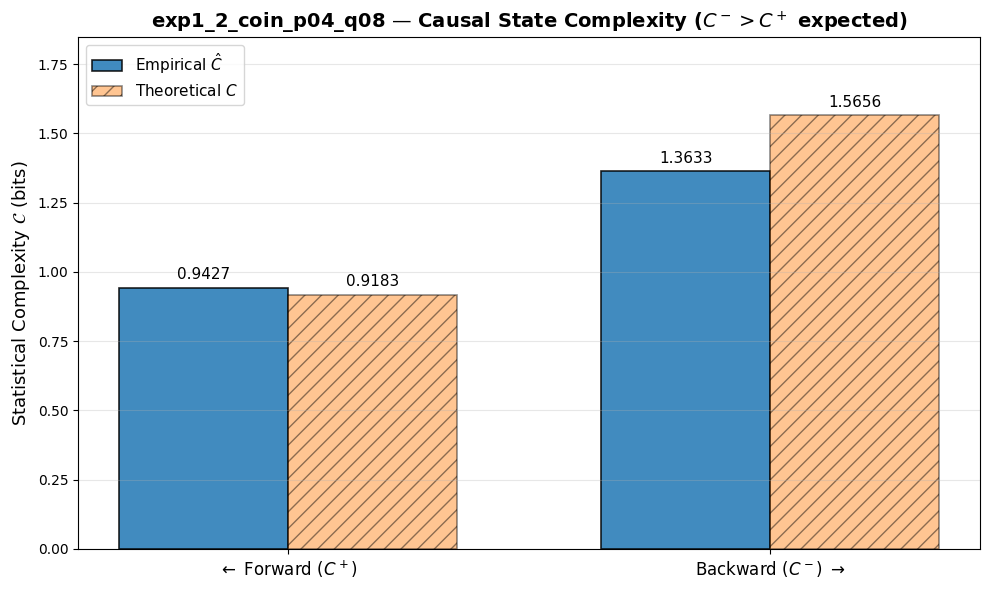

(<Figure size 1000x600 with 1 Axes>,
 <Axes: title={'center': 'exp1_2_coin_p04_q08 — Causal State Complexity ($C^- > C^+$ expected)'}, ylabel='Statistical Complexity $\\mathcal{C}$ (bits)'>)

In [1]:
%matplotlib inline

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# ---------------------------------------------------------------------
# Data from the shown plot
# ---------------------------------------------------------------------

complexity_data = [
    {
        "tag": "exp1_2_coin_p04_q08",
        "p": 0.4,
        "q": 0.8,
        "C_plus_emp": 0.9427,
        "C_plus_theory": 0.9183,
        "C_minus_emp": 1.3633,
        "C_minus_theory": 1.5656,
    }
]

df_c = pd.DataFrame(complexity_data)

OUT_ROOT = Path("results/asymmetry_test")
OUT_ROOT.mkdir(parents=True, exist_ok=True)


# ---------------------------------------------------------------------
# Plot function
# ---------------------------------------------------------------------

def plot_causal_state_complexity(row, out_root=OUT_ROOT, show=True):
    tag = row["tag"]
    p = row["p"]
    q = row["q"]

    out_dir = out_root / tag
    out_dir.mkdir(parents=True, exist_ok=True)

    groups = [r"$\leftarrow$ Forward $(C^+)$", r"Backward $(C^-)$ $\rightarrow$"]

    empirical = [
        row["C_plus_emp"],
        row["C_minus_emp"],
    ]

    theoretical = [
        row["C_plus_theory"],
        row["C_minus_theory"],
    ]

    x = np.arange(len(groups))
    width = 0.35

    fig, ax = plt.subplots(figsize=(10, 6))

    bars_emp = ax.bar(
        x - width / 2,
        empirical,
        width,
        label=r"Empirical $\hat{C}$",
        edgecolor="black",
        linewidth=1.2,
        alpha=0.85,
    )

    bars_theory = ax.bar(
        x + width / 2,
        theoretical,
        width,
        label=r"Theoretical $C$",
        edgecolor="black",
        linewidth=1.2,
        alpha=0.45,
        hatch="//",
    )

    ax.bar_label(bars_emp, fmt="%.4f", padding=4, fontsize=11)
    ax.bar_label(bars_theory, fmt="%.4f", padding=4, fontsize=11)

    ax.set_xticks(x)
    ax.set_xticklabels(groups, fontsize=12)

    ax.set_ylabel(r"Statistical Complexity $\mathcal{C}$ (bits)", fontsize=13)

    ax.set_title(
        rf"{tag} — Causal State Complexity "
        rf"($C^- > C^+$ expected)",
        fontsize=14,
        fontweight="bold",
    )

    ymax = max(empirical + theoretical) * 1.18
    ax.set_ylim(0, ymax)

    ax.grid(axis="y", alpha=0.3)
    ax.legend(fontsize=11)

    fig.tight_layout()

    out_path = out_dir / f"{tag}_causal_state_complexity.png"
    fig.savefig(out_path, dpi=200, bbox_inches="tight")
    print("saved:", out_path)

    if show:
        plt.show()

    return fig, ax


# ---------------------------------------------------------------------
# Plot the case
# ---------------------------------------------------------------------

plot_causal_state_complexity(df_c.iloc[0])